# 05 - Visualização da variável alvo
Este notebook cria uma visualização simples da distribuição do diagnóstico na base original.

O objetivo é verificar rapidamente quantos casos benignos e malignos existem, ajudando a entender se há equilíbrio entre as classes antes da modelagem.

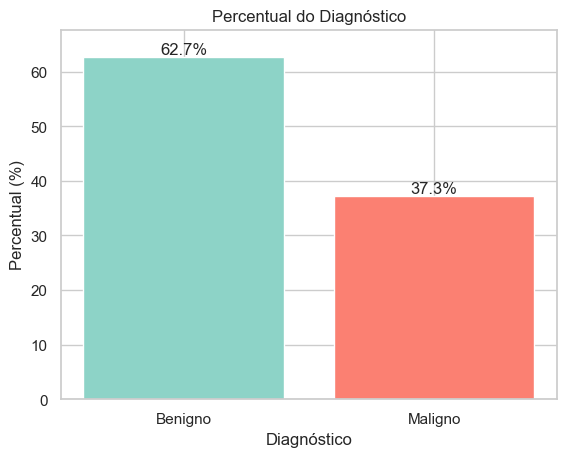

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o dataset original para visualizar a distribuição do diagnóstico.
df = pd.read_csv('../data/breast-cancer-wisconsin-data-clean.csv')

sns.set_theme(style='whitegrid')

# Identificar a coluna de diagnóstico no dataset.
coluna_diagnostico = 'diagnostico' if 'diagnostico' in df.columns else 'diagnosis'

# Calcular o percentual de casos benignos e malignos.
percentuais = (
    df[coluna_diagnostico]
    .replace({'B': 'Benigno', 'M': 'Maligno', 0: 'Benigno', 1: 'Maligno'})
    .value_counts(normalize=True)
    .reindex(['Benigno', 'Maligno'])
    .mul(100)
)

# Exibir o percentual de casos em cada classe do diagnóstico.
barras = plt.bar(
    percentuais.index,
    percentuais.values,
    color=['#8dd3c7', '#fb8072']
)

plt.title('Percentual do Diagnóstico')
plt.xlabel('Diagnóstico')
plt.ylabel('Percentual (%)')

for barra, valor in zip(barras, percentuais.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.5,
        f'{valor:.1f}%',
        ha='center'
    )

plt.ylim(0, percentuais.max() + 5)
plt.show()